# Results notebook for the Muon paper

This notebook is the cleaned paper-artifact notebook. It only contains the code needed to load the current experiment results and generate the figures/tables used by the paper and its appendix.

Artifacts are written to `assets/`.


In [39]:
import functools
import os
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.colors
import matplotlib.patches as mpatches
import matplotlib.ticker
import numpy as np
import pandas as pd
import seaborn as sns
from loguru import logger
from scipy import stats

# Add LaTeX to PATH (non-standard location)
os.environ['PATH'] = '/usr/local/texlive/2025/bin/universal-darwin:' + os.environ.get('PATH', '')

import lib.paper_data as devdata
import lib.results as devresults
import lib.util
import lib.env

lib.util.init_notebook(torch_=False)
pd.set_option('display.max_rows', 2000)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 0)

# Output directory for generated paper assets
OUTPUT_DIR = Path('assets')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [40]:
def setup_plot_style():
    """Configure matplotlib style for publication-quality figures with LaTeX."""
    style_params = {
        # Axes
        'axes.linewidth': 1,
        'axes.axisbelow': True,
        'axes.ymargin': 0.1,
        'axes.spines.bottom': True,
        'axes.spines.left': True,
        'axes.spines.right': False,
        'axes.spines.top': False,
        'axes.grid': False,
        
        # Grid
        'grid.color': 'black',
        'grid.linewidth': 0.1,
        
        # X ticks
        'xtick.bottom': True,
        'xtick.top': False,
        'xtick.direction': 'out',
        'xtick.major.size': 5,
        'xtick.major.width': 1,
        'xtick.minor.size': 3,
        'xtick.minor.width': 0.5,
        'xtick.minor.visible': True,
        
        # Y ticks
        'ytick.left': True,
        'ytick.right': False,
        'ytick.direction': 'out',
        'ytick.major.size': 5,
        'ytick.major.width': 1,
        'ytick.minor.size': 3,
        'ytick.minor.width': 0.5,
        'ytick.minor.visible': True,
        
        # Lines
        'lines.linewidth': 2,
        'lines.markersize': 5,
        
        # Font settings
        'font.family': 'serif',
        'font.size': 12,
        'axes.titlesize': 22,
        'axes.labelsize': 20,
        'xtick.labelsize': 14,
        'ytick.labelsize': 14,
        'figure.titlesize': 22,
        
        # LaTeX settings
        'text.usetex': True,
        'font.serif': ['Times New Roman'] + plt.rcParams['font.serif'],
        'text.latex.preamble': r"""
            \usepackage[utf8]{inputenc}
            \usepackage[T1]{fontenc}
            \usepackage{mathptmx}
            \usepackage{amsmath}
            \usepackage{amssymb}
            \usepackage{amsfonts}
            \usepackage{bm}
        """,
    }
    
    plt.rcParams.update(style_params)


# Apply style
setup_plot_style()

# Color palette for plots
COLORS = {
    'black': '#000000',
    'blue': '#80B1D3',
    'darkgray': '#636363',
    'gray': '#D9D9D9',
    'green': '#7CCA72',
    'orange': '#FDB462',
    'purple': '#BC80BD',
    'red': '#FB8072',
    'teal': '#8DD3C7',
}

# Plot style constants
BARPLOT_ALPHA = 0.65
BOXPLOT_ALPHA = 0.4
GRID_ALPHA = 0.5
JITTERPLOT_ALPHA = 0.45
JITTERPLOT_LINEWIDTH = 0.45
LEGEND_ALPHA = 0.9
MEAN_ALPHA = 1.0
MEAN_LINEWIDTH = 1.0
MEAN_MARKER = 'd'
MEAN_MARKER_SIZE = 150
MEAN_ZORDER = 10

In [41]:
# Clear cache when experiment files change on disk
devresults.clear_cache()

wrap = devdata.wrap_dataset_name

# 17 datasets total: 9 default + 8 TabRed
datasets = [
    # Default (9)
    devdata.CHURN,
    devdata.CALIFORNIA,
    devdata.HOUSE,
    devdata.ADULT,
    devdata.DIAMOND,
    devdata.OTTO,
    devdata.HIGGS_SMALL,
    devdata.BLACK_FRIDAY,
    devdata.MICROSOFT,
    # TabRed (8)
    devdata.SBERBANK_HOUSING,
    devdata.ECOM_OFFERS,
    devdata.MAPS_ROUTING,
    devdata.HOMESITE_INSURANCE,
    devdata.COOKING_TIME,
    devdata.HOMECREDIT_DEFAULT,
    devdata.DELIVERY_ETA,
    devdata.WEATHER,
]

print(f'Total datasets: {len(datasets)}')

Total datasets: 17


In [42]:
def build_dataframes(
    *args,
    num_statistics: None | list[str] = None,
    reference_names: None | list[str] = None,
    absolute_metrics: None | list[str] = None,
    drop_reference_rows: bool = False,
    rank_columns: None | list[str] = None,
    **kwargs,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Args:
        args: the positional arguments for `devresults.load_dataframe`.
        kwargs: the keyword arguments for `devresults.load_dataframe`.
        num_statistics: the statistics for `devresults.aggregate_all_columns`.
        reference_names: the reference names for `devresults.compute_relative_metrics_`.
        absolute_metrics: the metric columns for `devresults.compute_relative_metrics_`.
        drop_reference_rows: if True, the rows with the reference names will be dropped.
        rank_columns: the columns for rank computation.
    """
    # Create the dataframe.
    df = devresults.load_dataframe(*args, **kwargs)
    first_name = df[['Name']].iloc[0, 0]

    # Aggregate all columns.
    df = devresults.aggregate_all_columns(
        df,
        ['mean', 'std'] if num_statistics is None else num_statistics,
        by=['Dataset.name', 'Name'],
    )

    # Compute relative metrics.
    for reference_name in [first_name] if reference_names is None else reference_names:
        devresults.compute_relative_metrics_(
            df,
            reference_name,
            (
                ['metrics.test.unified_score.mean']
                if absolute_metrics is None
                else absolute_metrics
            ),
            by='Dataset.name',
        )
        if drop_reference_rows:
            df = df.loc[df.index.get_level_values('Name') != reference_name]

    # Drop datasets where not all models are available.
    complete_df = devresults.drop_incomplete_datasets(df)
    all_datasets_are_complete = len(df) == len(complete_df)
    if not all_datasets_are_complete:
        incomplete_datasets = set(df.index.unique('Dataset.name')) - set(
            complete_df.index.unique('Dataset.name')
        )
        logger.warning(f'Incomplete datasets: {", ".join(incomplete_datasets)}')

    # Compute ranks.
    default_rank_column = 'metrics.test.score'
    for rank_column in (
        ([default_rank_column] if f'{default_rank_column}.mean' in df.columns else [])
        if rank_columns is None
        else rank_columns
    ):
        df = devresults.compute_ranks(
            df, f'{rank_column}.mean', f'{rank_column}.std', by='Dataset.name'
        )
        complete_df = (
            df
            if all_datasets_are_complete
            else devresults.compute_ranks(
                complete_df,
                f'{rank_column}.mean',
                f'{rank_column}.std',
                by='Dataset.name',
            )
        )

    # Sort the dataframes.
    for df_ in (df, complete_df):
        df_.sort_values(
            ['Dataset.train_size', 'Dataset.name', 'metrics.test.score.mean', 'Name'],
            ascending=[True, True, False, True],
            inplace=True,
        )

    return df, complete_df


def show_column(series: pd.Series) -> None:
    """Display formatted statistics for a column."""
    assert isinstance(series.name, str)
    try:
        prefix, suffix = series.name.rsplit('.', 1)
    except ValueError:
        raise ValueError(f'Cannot summarize the column: {series.name}')

    if suffix == 'rank':
        print(f'Ranks by {prefix}')
        display(series.groupby('Name').agg(['mean', 'std']).sort_values('mean'))

    elif prefix.endswith('.relative'):
        print(f'Relative to {suffix}')
        display(
            series.groupby('Name')
            .agg(
                **{
                    'mean': 'mean',
                    'std': 'std',
                    'iqm1': lambda x: devresults.interquantile_mean(x, None, 0.25),
                    'iqm23': lambda x: devresults.interquantile_mean(x, 0.25, 0.75),
                    'iqm4': lambda x: devresults.interquantile_mean(x, 0.75, None),
                    'min': 'min',
                    'median': 'median',
                    'max': 'max',
                }
            )
            .sort_values('mean', ascending=False)
        )

    else:
        raise ValueError(f'Cannot summarize the column: {series.name}')


def compute_wins_ties_losses(
    df: pd.DataFrame,
    method1: str,
    method2: str,
    score_col: str = 'metrics.test.unified_score.mean',
    std_col: str = 'metrics.test.unified_score.std',
    alpha: float = 0.05,
    n_samples: int = 10,
) -> tuple[int, int, int]:
    """Compute W/T/L for method2 vs method1 (wins = method2 better) using t-test."""
    wins, ties, losses = 0, 0, 0
    
    datasets_available = df.index.get_level_values('Dataset.name').unique()
    for dataset in datasets_available:
        try:
            score1 = df.loc[(dataset, method1), score_col]
            score2 = df.loc[(dataset, method2), score_col]
            std1 = df.loc[(dataset, method1), std_col]
            std2 = df.loc[(dataset, method2), std_col]
        except KeyError:
            continue
        
        # Use Welch's t-test for comparing means
        t_stat, p_value = stats.ttest_ind_from_stats(
            score1, std1, n_samples,
            score2, std2, n_samples,
            equal_var=False
        )
        if p_value < alpha:
            if score2 > score1:
                wins += 1
            else:
                losses += 1
        else:
            ties += 1
    
    return wins, ties, losses


def make_tick_label(name: str, scores: pd.Series | None = None) -> str:
    """Create formatted tick label with LaTeX rendering."""
    label = '$\\mathrm{' + name.replace(' ', r'\;').replace('-', r'\mbox{-}') + '}$'
    if scores is None:
        return label
    else:
        mean = f'{scores.mean():.2f}'
        std = f'{scores.std():.1f}'
        return label + '\n{\\small $ ' + mean + ' \\pm ' + std + '\\% $}'

def compute_ttest_ranks(
    df: pd.DataFrame,
    score_col: str = 'metrics.test.unified_score.mean',
    std_col: str = 'metrics.test.unified_score.std',
    alpha: float = 0.05,
    n_samples: int = 10,
) -> pd.Series:
    """Compute ranks using pairwise t-tests instead of raw scores.

    For each dataset, methods are ranked by the number of pairwise
    significant wins (more wins → lower/better rank).  Ties in win-count
    are broken by the raw score.

    This is a drop-in replacement for the rank column produced by
    ``devresults.compute_ranks`` and can be plugged into the figure code
    by replacing ``rank_col`` with the series returned here.

    Returns a Series indexed like *df* (Dataset.name, Name) containing
    per-dataset ranks (1 = best).
    """
    datasets = df.index.get_level_values('Dataset.name').unique()
    methods = df.index.get_level_values('Name').unique()

    all_ranks = {}
    for dataset in datasets:
        # Count pairwise significant wins for each method
        win_counts: dict[str, int] = {m: 0 for m in methods}
        available = [m for m in methods if (dataset, m) in df.index]

        for i, m1 in enumerate(available):
            for m2 in available[i + 1:]:
                s1 = df.loc[(dataset, m1), score_col]
                s2 = df.loc[(dataset, m2), score_col]
                sd1 = df.loc[(dataset, m1), std_col]
                sd2 = df.loc[(dataset, m2), std_col]
                _, p_value = stats.ttest_ind_from_stats(
                    s1, sd1, n_samples, s2, sd2, n_samples, equal_var=False,
                )
                if p_value < alpha:
                    if s2 > s1:
                        win_counts[m2] += 1
                    else:
                        win_counts[m1] += 1

        # Build ranking: more wins → better; break ties by raw score (desc)
        ranking_key = sorted(
            available,
            key=lambda m: (-win_counts[m], -df.loc[(dataset, m), score_col]),
        )
        for rank, m in enumerate(ranking_key, start=1):
            all_ranks[(dataset, m)] = rank

    result = pd.Series(all_ranks, name='ttest_rank')
    result.index = pd.MultiIndex.from_tuples(result.index, names=['Dataset.name', 'Name'])
    return result


## Transfer results across MLP-based architectures

Load the AdamW / AdamW+EMA / Muon / Muon+EMA results used in the main transfer table and appendix summaries.


In [43]:
# fmt: off
df_muon, complete_df_muon = build_dataframes(
    {
        # AdamW versions
        'MLP[AdamW]': [f'exp/mlp/adamw/{wrap(d)}/evaluation' for d in datasets],
        'MLP-PLE[AdamW]': [f'exp/mlp-piecewiselinear/adamw/{wrap(d)}/evaluation' for d in datasets],
        'TabM-Packed[AdamW]': [f'exp/tabm-packed/adamw/{wrap(d)}/evaluation' for d in datasets],
        'TabM[AdamW]': [f'exp/tabm/adamw/{wrap(d)}/evaluation' for d in datasets],
        'TabM-PLE[AdamW]': [f'exp/tabm-piecewiselinear/adamw/{wrap(d)}/evaluation' for d in datasets],

        # AdamW + EMA versions
        'MLP[AdamW EMA]': [f'exp/mlp/adamw-ema/{wrap(d)}/evaluation' for d in datasets],
        'MLP-PLE[AdamW EMA]': [f'exp/mlp-piecewiselinear/adamw-ema/{wrap(d)}/evaluation' for d in datasets],
        'TabM-Packed[AdamW EMA]': [f'exp/tabm-packed/adamw-ema/{wrap(d)}/evaluation' for d in datasets],
        'TabM[AdamW EMA]': [f'exp/tabm/adamw-ema/{wrap(d)}/evaluation' for d in datasets],
        'TabM-PLE[AdamW EMA]': [f'exp/tabm-piecewiselinear/adamw-ema/{wrap(d)}/evaluation' for d in datasets],

        # Muon
        'MLP[Muon]': [f'exp/mlp/muon/{wrap(d)}/evaluation' for d in datasets],
        'MLP-PLE[Muon]': [f'exp/mlp-piecewiselinear/muon/{wrap(d)}/evaluation' for d in datasets],
        'TabM[Muon]': [f'exp/tabm/muon/{wrap(d)}/evaluation' for d in datasets],
        'TabM-Packed[Muon]': [f'exp/tabm-packed/muon/{wrap(d)}/evaluation' for d in datasets],
        'TabM-PLE[Muon]': [f'exp/tabm-piecewiselinear/muon/{wrap(d)}/evaluation' for d in datasets],
        'MLP[Muon EMA]': [f'exp/mlp/muon-ema/{wrap(d)}/evaluation' for d in datasets],

    },
    reference_names=['MLP[AdamW]'],
    allow_skipping=True,
    cache=True,
)
# fmt: on

print('\n=== Muon/EMA Transfer Comparison ===')
show_column(complete_df_muon['metrics.test.score.mean.rank'])
show_column(complete_df_muon['metrics.test.unified_score.mean.relative.MLP[AdamW]'])



=== Muon/EMA Transfer Comparison ===
Ranks by metrics.test.score.mean


,mean,std
Name,,
TabM-PLE[Muon],1.941176,1.248529
TabM-PLE[AdamW EMA],2.647059,1.617914
TabM-PLE[AdamW],2.764706,1.562426
TabM[Muon],2.882353,1.536325
TabM[AdamW EMA],3.235294,1.393261
TabM[AdamW],3.882353,1.653872
MLP-PLE[Muon],4.176471,2.007339
TabM-Packed[Muon],4.588235,2.001837
MLP-PLE[AdamW EMA],4.705882,1.992633


Relative to MLP[AdamW]


,mean,std,iqm1,iqm23,iqm4,min,median,max
Name,,,,,,,,
TabM-PLE[Muon],2.568088,3.371788,0.050996,1.420362,6.418121,-0.574481,1.478815,13.351232
TabM-PLE[AdamW EMA],2.210872,3.425752,-0.639263,1.291051,5.962693,-3.112738,1.427104,12.909648
TabM-PLE[AdamW],2.168051,3.074546,-0.265886,1.161799,5.725204,-1.398980,1.250011,11.843757
TabM[AdamW EMA],1.751581,1.898156,-0.029131,1.101579,4.216155,-0.746566,1.248073,6.034955
TabM[Muon],1.709050,1.682468,0.315124,1.054605,3.871304,0.151799,1.085346,5.398338
MLP-PLE[Muon],1.556777,2.415572,-0.253062,0.721009,4.341876,-0.723761,0.766541,9.386549
TabM[AdamW],1.495247,1.649074,-0.053220,0.913886,3.664197,-0.736200,1.096210,5.073972
TabM-Packed[Muon],1.447838,1.778499,-0.036117,0.741203,3.765618,-0.226054,0.620198,4.903945
MLP-PLE[AdamW EMA],1.416820,2.663186,-0.391313,0.562219,4.230690,-1.262423,0.529737,10.473700


## Main optimizer benchmark on MLP

Load the optimizer benchmark results and generate the main comparison figure.


In [44]:
# fmt: off
df_optimizers, complete_df_optimizers = build_dataframes(
    {
        # Baseline (blue)
        'SGD': [f'exp/mlp/sgd/{wrap(d)}/evaluation' for d in datasets],
        'AdamW': [f'exp/mlp/adamw/{wrap(d)}/evaluation' for d in datasets],
        'AdamW EMA': [f'exp/mlp/adamw-ema/{wrap(d)}/evaluation' for d in datasets],
        'NAdamW': [f'exp/mlp/nadamw/{wrap(d)}/evaluation' for d in datasets],
                'Adan': [f'exp/mlp/adan/{wrap(d)}/evaluation' for d in datasets],
        'RAdam': [f'exp/mlp/radam/{wrap(d)}/evaluation' for d in datasets],
        'AdaBelief': [f'exp/mlp/adabelief/{wrap(d)}/evaluation' for d in datasets],
        'ADOPT': [f'exp/mlp/adopt/{wrap(d)}/evaluation' for d in datasets],
        'Lion': [f'exp/mlp/lion/{wrap(d)}/evaluation' for d in datasets],
        'Signum': [f'exp/mlp/signum/{wrap(d)}/evaluation' for d in datasets],
        'AdEMAMix': [f'exp/mlp/ademamix/{wrap(d)}/evaluation' for d in datasets],
        'SOAP': [f'exp/mlp/soap/{wrap(d)}/evaluation' for d in datasets],
        'ScheduleFree': [f'exp/mlp/schedulefree/{wrap(d)}/evaluation' for d in datasets],
        'Cautious AdamW': [f'exp/mlp/cautious-adamw/{wrap(d)}/evaluation' for d in datasets],
        'Muon': [f'exp/mlp/muon/{wrap(d)}/evaluation' for d in datasets],
    },
    reference_names=['AdamW'],
    allow_skipping=True,
    cache=True,
)
# fmt: on

print('\n=== Optimizer Comparison ===')
show_column(complete_df_optimizers['metrics.test.score.mean.rank'])
show_column(complete_df_optimizers['metrics.test.unified_score.mean.relative.AdamW'])


=== Optimizer Comparison ===
Ranks by metrics.test.score.mean


,mean,std
Name,,
Muon,1.705882,0.919559
AdamW EMA,1.764706,0.664211
ScheduleFree,1.764706,1.032558
AdEMAMix,2.647059,1.455214
AdaBelief,2.647059,1.271868
SOAP,2.647059,1.411612
Adan,2.764706,1.437420
Cautious AdamW,2.764706,1.437420
ADOPT,3.058824,1.434860


Relative to AdamW


,mean,std,iqm1,iqm23,iqm4,min,median,max
Name,,,,,,,,
ScheduleFree,0.716729,1.462568,-0.157957,0.222231,2.207674,-0.328463,0.219467,5.872330
AdamW EMA,0.658148,1.032618,-0.088917,0.277120,1.865447,-0.179778,0.227951,3.987194
ADOPT,0.359567,1.176992,-0.318134,0.009247,1.462240,-0.401583,0.028803,4.704819
Muon,0.320900,0.937262,-0.788941,0.381410,1.111957,-2.738467,0.464047,1.544261
Adan,0.281578,0.748527,-0.327848,0.087053,1.080358,-0.708960,0.098675,2.679162
AdEMAMix,0.205507,0.515357,-0.137906,-0.003235,0.814223,-0.261553,0.003532,1.795117
Cautious AdamW,0.133900,0.474394,-0.278894,-0.010007,0.694387,-0.384123,0.004659,1.523636
SOAP,0.068021,1.281065,-1.317113,0.116937,1.097861,-4.167538,0.168153,2.256352
NAdamW,0.047463,0.291306,-0.279528,0.004966,0.377051,-0.321350,0.040235,0.804144


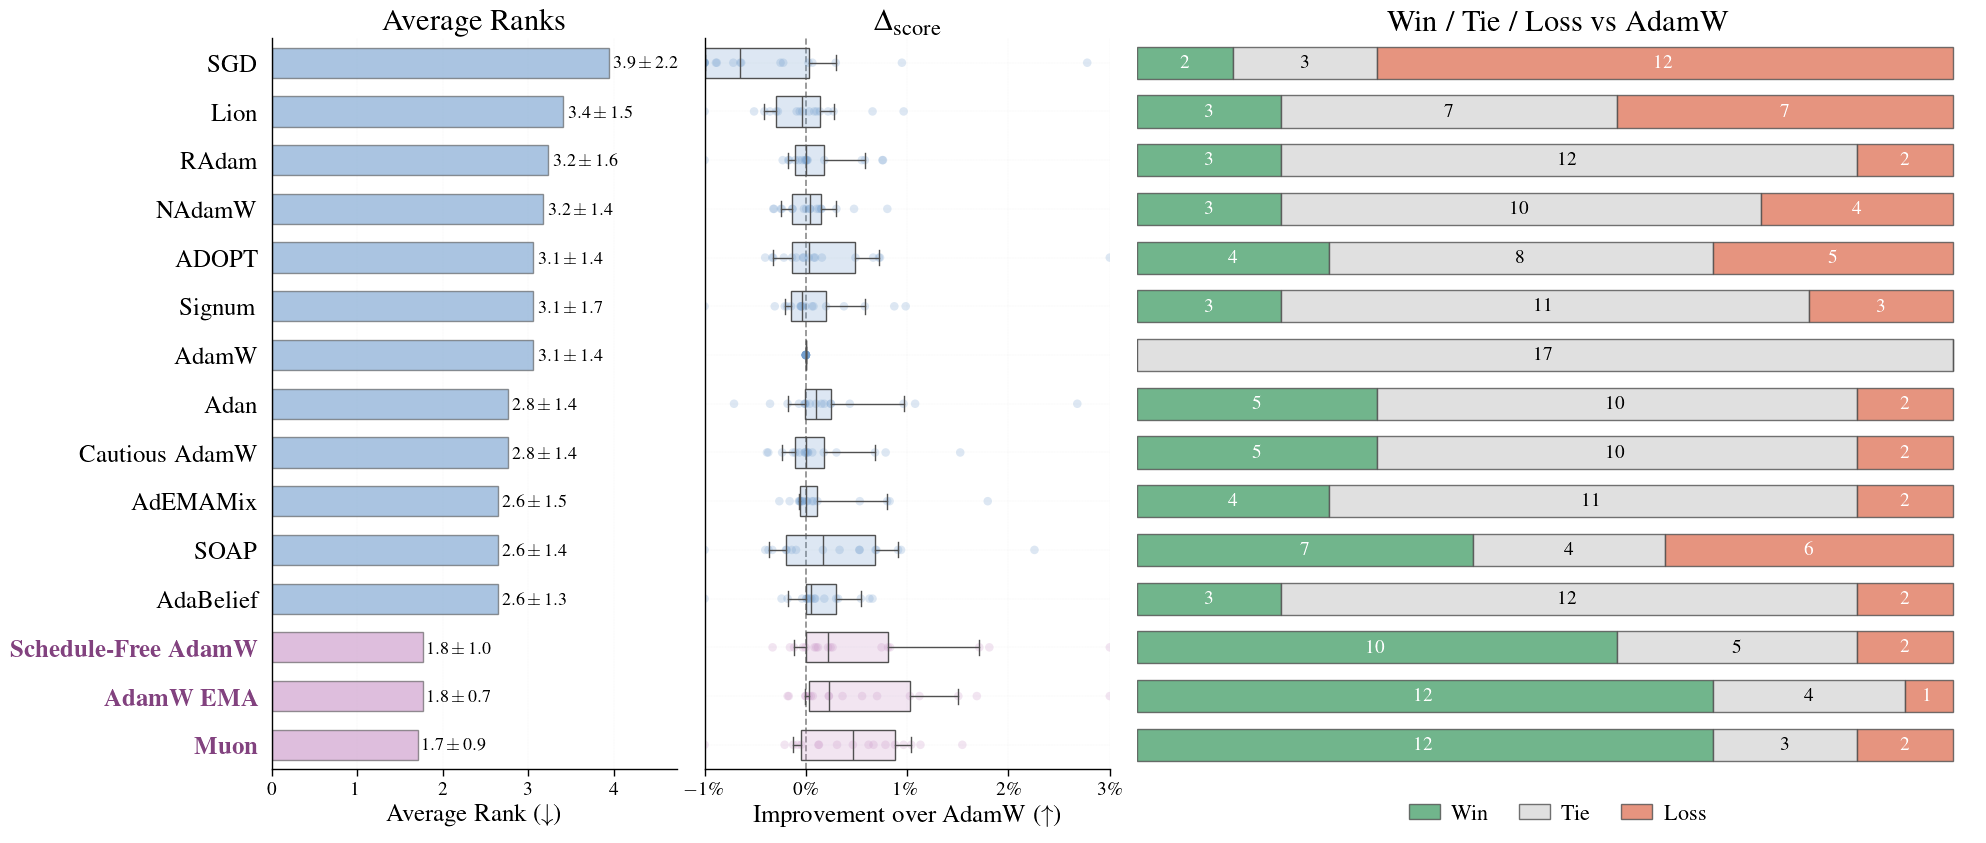

In [45]:
import matplotlib.colors
import matplotlib.ticker as mtick
from matplotlib.patches import Patch


def create_optimizer_comparison_figure(
    df: pd.DataFrame,
    output_path: Path,
) -> pd.DataFrame:
    reference = 'AdamW'
    rank_col = 'metrics.test.score.mean.rank'
    rel_col = f'metrics.test.unified_score.mean.relative.{reference}'

    optimizers = [
        'SGD',
        'Lion',
        'NAdamW',
        'Signum',
        'RAdam',
        'AdamW',
        'ADOPT',
        'Adan',
        'Cautious AdamW',
        'AdaBelief',
        'AdEMAMix',
        'AdamW EMA',
        'ScheduleFree',
        'SOAP',
        'Muon',
    ]

    display_name = {
        'SGD': 'SGD',
        'AdamW': 'AdamW',
        'AdamW EMA': r'\textbf{AdamW EMA}',
        'NAdamW': 'NAdamW',
        'RAdam': 'RAdam',
        'AdaBelief': 'AdaBelief',
        'Adan': 'Adan',
        'ADOPT': 'ADOPT',
        'Lion': 'Lion',
        'AdEMAMix': 'AdEMAMix',
        'Cautious AdamW': 'Cautious AdamW',
        'ScheduleFree': r'\textbf{Schedule-Free AdamW}',
        'Signum': 'Signum',
        'SOAP': 'SOAP',
        'Muon': r'\textbf{Muon}',
    }

    # --- Winners: methods that outperform AdamW ---
    winners = {
        'AdamW EMA',
        'ScheduleFree',
        'Muon',
    }

    # --- Color scheme ---
    color_winner = '#C994C7'      # saturated purple — the story
    color_default = '#729ECE'     # muted blue — clearly chromatic, not gray

    wtl_colors = {
        'wins': '#4EA36F',
        'ties': '#D9D9D9',
        'losses': '#E07A5F',
    }

    edgecolor = '#505050'
    rank_alpha = 0.6
    box_alpha = 0.24
    point_alpha = 0.24
    wtl_alpha = 0.8
    grid_alpha = 0.18

    def _color_for(opt):
        return color_winner if opt in winners else color_default

    rows = []
    for opt in optimizers:
        ranks = df.xs(opt, level='Name')[rank_col]
        rel = df.xs(opt, level='Name')[rel_col]
        w, t, l = compute_wins_ties_losses(df, reference, opt)
        rows.append(
            {
                'internal_name': opt,
                'display_name': display_name[opt],
                'rank_mean': ranks.mean(),
                'rank_std': ranks.std(),
                'rel_mean': rel.mean(),
                'rel_std': rel.std(),
                'wins': w,
                'ties': t,
                'losses': l,
            }
        )

    summary_df = (
        pd.DataFrame(rows)
        .sort_values(['rank_mean', 'rel_mean'], ascending=[True, True])
        .reset_index(drop=True)
    )

    order_internal = summary_df['internal_name'].tolist()
    order_display = summary_df['display_name'].tolist()
    y = np.arange(len(summary_df))

    rel_plot_df = (
        df.loc[(slice(None), order_internal), [rel_col]]
        .reset_index()[['Dataset.name', 'Name', rel_col]]
        .copy()
    )
    xlim_rel = (-1.0, 3.0)
    rel_plot_df['rel_clipped'] = rel_plot_df[rel_col].clip(*xlim_rel)

    fig, (ax_rank, ax_rel, ax_wtl) = plt.subplots(
        1,
        3,
        figsize=(22, 8.4),
        sharey=True,
        gridspec_kw={'width_ratios': [1.4, 1.4, 2.9], 'wspace': 0.05},
    )
    fig.subplots_adjust(left=0.22, right=0.995, top=0.90, bottom=0.11)

    # --- ranks ---
    rank_means = summary_df['rank_mean'].to_numpy()
    rank_stds = summary_df['rank_std'].to_numpy()
    bar_colors = [_color_for(opt) for opt in order_internal]

    ax_rank.barh(
        y, rank_means,
        color=bar_colors,
        edgecolor=edgecolor,
        linewidth=1.0,
        height=0.62,
        alpha=rank_alpha,
    )
    for i, (mean, std) in enumerate(zip(rank_means, rank_stds)):
        ax_rank.text(
            mean + 0.05, i,
            rf'${mean:.1f} \pm {std:.1f}$',
            ha='left', va='center', fontsize=13,
        )

    ax_rank.set_title('Average Ranks', fontsize=22)
    ax_rank.set_xlabel(r'Average Rank ($\downarrow$)', fontsize=18)
    ax_rank.set_xlim(0, max(rank_means) + 0.8)
    ax_rank.grid(True, axis='x', linestyle='--', alpha=grid_alpha)
    ax_rank.tick_params(axis='x', labelsize=14)

    # --- relative improvement ---
    line_props = {'color': edgecolor, 'linewidth': 1.0}
    for i, opt in enumerate(order_internal):
        vals = rel_plot_df.loc[rel_plot_df['Name'] == opt, 'rel_clipped'].values
        color = _color_for(opt)

        ax_rel.boxplot(
            [vals],
            positions=[i],
            whis=(10, 90),
            showfliers=False,
            vert=False,
            widths=0.62,
            patch_artist=True,
            boxprops=line_props | {'facecolor': (*matplotlib.colors.to_rgb(color), box_alpha)},
            medianprops=line_props,
            whiskerprops=line_props,
            capprops=line_props,
        )
        ax_rel.scatter(
            vals,
            np.full_like(vals, i, dtype=float),
            s=38,
            color=(*matplotlib.colors.to_rgb(color), point_alpha),
            edgecolor='none',
            zorder=1,
        )

    ax_rel.axvline(0, color='gray', linestyle='--', linewidth=1.2, alpha=0.9, zorder=0)
    ax_rel.set_title(r'$\Delta_{\text{score}}$', fontsize=22)
    ax_rel.set_xlabel(r'Improvement over AdamW ($\uparrow$)', fontsize=18)
    ax_rel.set_xlim(*xlim_rel)
    ax_rel.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
    ax_rel.grid(True, axis='both', linestyle='--', alpha=grid_alpha)
    ax_rel.tick_params(axis='x', labelsize=14)

    # --- WTL ---
    for i, row in summary_df.iterrows():
        w, t, l = int(row['wins']), int(row['ties']), int(row['losses'])

        ax_wtl.barh(i, w, color=wtl_colors['wins'], edgecolor=edgecolor, linewidth=1.0, height=0.66, alpha=wtl_alpha)
        ax_wtl.barh(i, t, left=w, color=wtl_colors['ties'], edgecolor=edgecolor, linewidth=1.0, height=0.66, alpha=wtl_alpha)
        ax_wtl.barh(i, l, left=w + t, color=wtl_colors['losses'], edgecolor=edgecolor, linewidth=1.0, height=0.66, alpha=wtl_alpha)

        if w >= 1:
            ax_wtl.text(w / 2, i, str(w), ha='center', va='center', fontsize=14, color='white')
        if t >= 1:
            ax_wtl.text(w + t / 2, i, str(t), ha='center', va='center', fontsize=14, color='black')
        if l >= 1:
            ax_wtl.text(w + t + l / 2, i, str(l), ha='center', va='center', fontsize=14, color='white')

    ax_wtl.set_title('Win / Tie / Loss vs AdamW', fontsize=22)
    ax_wtl.set_xlim(0, 17.5)
    ax_wtl.set_xticks([])

    handles = [
        Patch(facecolor=wtl_colors['wins'], edgecolor=edgecolor, alpha=wtl_alpha, label='Win'),
        Patch(facecolor=wtl_colors['ties'], edgecolor=edgecolor, alpha=wtl_alpha, label='Tie'),
        Patch(facecolor=wtl_colors['losses'], edgecolor=edgecolor, alpha=wtl_alpha, label='Loss'),
    ]

    ax_wtl.legend(
        handles=handles,
        ncol=3,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.02),
        frameon=False,
        fontsize=16,
        handlelength=1.4,
        columnspacing=1.4,
        handletextpad=0.5,
    )

    # --- Y-axis labels: bold + purple for winners, normal for others ---
    for ax in (ax_rank, ax_rel, ax_wtl):
        ax.set_yticks(y)
        ax.minorticks_off()

    ax_rank.set_yticks(y, labels=order_display)
    ax_rank.tick_params(axis='y', length=0, pad=10, labelsize=18)

    # Style winner labels: bold + purple
    for label, opt in zip(ax_rank.get_yticklabels(), order_internal):
        if opt in winners:
            #label.set_fontweight('bold')
            label.set_color('#82427f')

    ax_rel.tick_params(axis='y', left=False, labelleft=False)
    ax_wtl.tick_params(axis='y', left=False, labelleft=False)

    # --- spines ---
    for ax in (ax_rank, ax_rel, ax_wtl):
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    ax_wtl.spines['left'].set_visible(False)
    ax_wtl.spines['bottom'].set_visible(False)

    fig.subplots_adjust(bottom=0.03)
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.savefig(output_path.with_suffix('.pdf'), bbox_inches='tight')
    plt.show()

    return summary_df


summary_df = create_optimizer_comparison_figure(
    complete_df_optimizers,
    OUTPUT_DIR / 'optimizer_comparison_3panel_axislabels.png',
)

## Main transfer table

Generate the paper transfer table across MLP-based architectures.


In [46]:
def generate_transfer_table(
    df: pd.DataFrame,
    include_modernnca: bool = False,
    output_path: Path | None = None,
    caption: str = (r"""
Transfer of optimizer gains across MLP-based architectures. $\Delta_{\mathrm{score}}$
denotes the mean relative score improvement with respect to the MLP[AdamW]
baseline. The AdamW column thus shows the gain from the architecture alone. For
AdamW EMA and Muon we report the combined architecture+optimizer gain, and in
parentheses the additional gain over AdamW within the same architecture. W/T/L
compares each method to AdamW \textit{within the same model}. The last row
contains summary, which is mean for the $\Delta_{\mathrm{score}}$ columns and sum for
the W/T/L columns. Muon is the most consistent in terms of reliability of
improvement across architecture variants. EMA gains are less uniform across
architectures and datasets."""
    ),
    label: str = "tab:optimizer-transfer",
    highlight_delta: tuple[str, str] | None = ("MLP", "AdamW EMA"),
) -> tuple[pd.DataFrame, str]:
    model_specs = [
        ("MLP", "MLP"),
        ("MLP-PLE", r"MLP$^\dagger$"),
        ("TabM-Packed", r"TabM$_{\text{Packed}}$"),
        ("TabM", "TabM"),
        ("TabM-PLE", r"TabM$^\dagger$"),
    ]
    if include_modernnca:
        model_specs.append(("ModernNCA", "ModernNCA"))

    variants = [
        ("AdamW", "AdamW"),
        ("AdamW EMA", r"AdamW {\scriptsize EMA}"),
        ("Muon", "Muon"),
    ]
    compare_variants = variants[1:]

    rel_col = "metrics.test.unified_score.mean.relative.MLP[AdamW]"

    def method_name(model: str, variant: str) -> str:
        return f"{model}[{variant}]"

    def mean_score(model: str, variant: str) -> float:
        return df.xs(method_name(model, variant), level="Name")[rel_col].mean()

    def fmt_total(x: float, force_zero: bool = False) -> str:
        if force_zero:
            return "0.00"
        return f"{x:.2f}" if x >= 0 else f"-{abs(x):.2f}"

    def fmt_delta(x: float, highlighted: bool = False) -> str:
        if highlighted:
            if x >= 0:
                return rf"\textcolor{{OliveGreen}}{{+\textbf{{{abs(x):.2f}}}}}"
            return rf"\textcolor{{BrickRed}}{{-\textbf{{{abs(x):.2f}}}}}"
        return f"+{x:.2f}" if x >= 0 else f"-{abs(x):.2f}"

    def fmt_combined(total: float, delta: float, highlight: bool = False) -> str:
        return rf"{fmt_total(total)} {{\scriptsize ({fmt_delta(delta, highlighted=highlight)})}}"

    def fmt_wtl(w: int, t: int, l: int) -> str:
        return f"{w}/{t}/{l}"

    rows = []
    latex_rows = []

    adamw_scores = []
    delta_summaries = {variant_label: [] for _, variant_label in compare_variants}
    wtl_summaries = {variant_label: [0, 0, 0] for _, variant_label in compare_variants}

    for model_key, model_label in model_specs:
        try:
            scores = {variant: mean_score(model_key, variant) for variant, _ in variants}
        except KeyError:
            continue

        adamw_score = scores["AdamW"]
        force_zero = (model_key == "MLP")

        adamw_scores.append(adamw_score)

        row = {"Model": model_label, "AdamW": adamw_score}
        latex_cells = [model_label, fmt_total(adamw_score, force_zero=force_zero)]

        for variant_key, variant_label in compare_variants:
            total = scores[variant_key]
            delta = total - adamw_score
            do_highlight = True

            delta_summaries[variant_label].append(delta)

            row[variant_label] = total
            row[f"{variant_label} Δ over AdamW"] = delta
            latex_cells.append(fmt_combined(total, delta, highlight=do_highlight))

        for variant_key, variant_label in compare_variants:
            w, t, l = compute_wins_ties_losses(
                df,
                method_name(model_key, "AdamW"),
                method_name(model_key, variant_key),
            )
            wtl_summaries[variant_label][0] += w
            wtl_summaries[variant_label][1] += t
            wtl_summaries[variant_label][2] += l

            row[f"W/T/L {variant_label}"] = fmt_wtl(w, t, l)
            latex_cells.append(fmt_wtl(w, t, l))

        rows.append(row)
        latex_rows.append(" & ".join(latex_cells) + r" \\")

    result_df = pd.DataFrame(rows)

    overall_cells = [r"\textbf{Summary:}"]
    overall_cells.append(rf"\textbf{{{np.mean(adamw_scores):.2f}}}")

    for _, variant_label in compare_variants:
        mean_total = result_df[variant_label].mean()
        mean_delta = np.mean(delta_summaries[variant_label])
        overall_cells.append(
            rf"\textbf{{{mean_total:.2f}}} {{\scriptsize (\textbf{{{fmt_delta(mean_delta, highlighted=True)}}})}}"
        )

    for _, variant_label in compare_variants:
        w, t, l = wtl_summaries[variant_label]
        overall_cells.append(rf"\textbf{{{fmt_wtl(w, t, l)}}}")

    overall_latex = " & ".join(overall_cells) + r" \\"

    delta_header = r"$\Delta_{\mathrm{score}}$ over MLP[AdamW]"
    wtl_header = r"W/T/L vs \textit{Architecture}[AdamW]"

    latex = rf"""
\begin{{table*}}[h]
\centering
\caption{{{caption}}}
\label{{{label}}}
\small
\setlength{{\tabcolsep}}{{5pt}}
\renewcommand{{\arraystretch}}{{1.08}}
\begin{{tabular}}{{@{{}}lccc@{{\hspace{{16pt}}}}cc@{{}}}}
\toprule
& \multicolumn{{3}}{{c}}{{{delta_header}}} & \multicolumn{{2}}{{c}}{{{wtl_header}}} \\
\cmidrule(lr){{2-4}} \cmidrule(lr){{5-6}}
Model & AdamW & AdamW {{\scriptsize EMA}} & Muon & AdamW {{\scriptsize EMA}} & Muon \\
\midrule
{chr(10).join(latex_rows)}
\midrule
{overall_latex}
\bottomrule
\end{{tabular}}
\end{{table*}}
""".strip()

    if output_path is not None:
        output_path.write_text(latex)
        print(f"Saved: {output_path}")

    return result_df, latex


transfer_df, transfer_latex = generate_transfer_table(
    df_muon,
    include_modernnca=False,
    output_path=OUTPUT_DIR / "transfer_table.tex",
)

display(transfer_df)
print(transfer_latex)


Saved: assets/transfer_table.tex


,Model,AdamW,AdamW {\scriptsize EMA},AdamW {\scriptsize EMA} Δ over AdamW,Muon,Muon Δ over AdamW,W/T/L AdamW {\scriptsize EMA},W/T/L Muon
0,MLP,0.000000,0.658148,0.658148,0.320900,0.320900,12/4/1,12/3/2
1,MLP$^\dagger$,1.115596,1.416820,0.301225,1.556777,0.441181,8/6/3,10/7/0
2,TabM$_{\text{Packed}}$,1.236868,1.313404,0.076536,1.447838,0.210970,5/8/4,12/3/2
3,TabM,1.495247,1.751581,0.256334,1.709050,0.213804,8/7/2,11/5/1
4,TabM$^\dagger$,2.168051,2.210872,0.042821,2.568088,0.400037,2/10/5,10/7/0


\begin{table*}[h]
\centering
\caption{
Transfer of optimizer gains across MLP-based architectures. $\Delta_{\mathrm{score}}$
denotes the mean relative score improvement with respect to the MLP[AdamW]
baseline. The AdamW column thus shows the gain from the architecture alone. For
AdamW EMA and Muon we report the combined architecture+optimizer gain, and in
parentheses the additional gain over AdamW within the same architecture. W/T/L
compares each method to AdamW \textit{within the same model}. The last row
contains summary, which is mean for the $\Delta_{\mathrm{score}}$ columns and sum for
the W/T/L columns. Muon is the most consistent in terms of reliability of
improvement across architecture variants. EMA gains are less uniform across
architectures and datasets.}
\label{tab:optimizer-transfer}
\small
\setlength{\tabcolsep}{5pt}
\renewcommand{\arraystretch}{1.08}
\begin{tabular}{@{}lccc@{\hspace{16pt}}cc@{}}
\toprule
& \multicolumn{3}{c}{$\Delta_{\mathrm{score}}$ over MLP[AdamW]} & \

# Limitations: Computing Time to tune

In [47]:
import json
import statistics
from pathlib import Path

ROOTS = {
    "AdamW": lib.env.get_project_dir() / 'exp/mlp/adamw',
    "AdamW+EMA": lib.env.get_project_dir() / 'exp/mlp/adamw-ema',
    "Muon": lib.env.get_project_dir() / 'exp/mlp/muon',
}


def load_reports(root: Path):
    result = {}
    for path in root.rglob("tuning/report.json"):
        rel = path.relative_to(root)
        dataset = "/".join(rel.parts[:-2])  # handles tabred/subdataset too
        with path.open("r", encoding="utf-8") as f:
            report = json.load(f)
        result[dataset] = {
            "time": float(report["time"]),
            "trials": int(report["n_completed_trials"]),
        }
    return result

data = {name: load_reports(root) for name, root in ROOTS.items()}
common = sorted(set.intersection(*(set(x.keys()) for x in data.values())))

print(f"Common datasets: {len(common)}")
for d in common:
    print(d)
print()

summaries = {}
for name, runs in data.items():
    times = [runs[d]["time"] for d in common]
    summaries[name] = {
        "total_hours": sum(times) / 3600.0,
        "mean_hours": statistics.mean(times) / 3600.0,
        "median_hours": statistics.median(times) / 3600.0,
    }
    
    print(name, summaries[name])
    
print(summaries['Muon']['mean_hours'] / summaries['AdamW']['mean_hours'])
print(summaries['AdamW+EMA']['mean_hours'] / summaries['AdamW']['mean_hours'])

Common datasets: 17
adult
black-friday
california
churn
diamond
higgs-small
house
microsoft
otto
tabred/cooking-time
tabred/delivery-eta
tabred/ecom-offers
tabred/homecredit-default
tabred/homesite-insurance
tabred/maps-routing
tabred/sberbank-housing
tabred/weather

AdamW {'total_hours': 15.46110697689547, 'mean_hours': 0.9094768809938512, 'median_hours': 0.6762504845190173}
AdamW+EMA {'total_hours': 20.005422034389145, 'mean_hours': 1.1767895314346555, 'median_hours': 0.676462813863893}
Muon {'total_hours': 46.89924832551546, 'mean_hours': 2.7587793132656153, 'median_hours': 1.7813199180548287}
3.033369369709429
1.2939191265078585


## Appendix all-results table

Generate the per-dataset appendix table in the TabM-style format.


In [48]:
def generate_tabm_style_appendix(
    df: pd.DataFrame,
    methods: list[str],
    output_path: Path,
    caption: str,
    label: str,
    score_col: str = 'metrics.test.unified_score.mean',
    std_col: str = 'metrics.test.unified_score.std',
    higher_is_better: dict[str, bool] | None = None,
) -> str:
    """
    Generate TabM-style appendix table with datasets grouped side-by-side.

    Args:
        df: DataFrame with results
        methods: List of method names to include
        output_path: Path to save LaTeX file
        caption: Table caption
        label: Table label
        score_col: Column for score mean
        std_col: Column for score std
        higher_is_better: Dict mapping dataset names to direction (True=higher better)

    Returns:
        LaTeX string
    """

    # Get all datasets
    all_datasets = df.index.get_level_values('Dataset.name').unique().tolist()

    # Clean dataset names for display
    def clean_dataset_name(name: str) -> str:
        return name.rsplit('data/', 1)[-1].replace('tabred/', '').replace('-', ' ').title().replace(' ', '-')

    # For unified_score, higher is always better
    if higher_is_better is None:
        higher_is_better = {d: True for d in all_datasets}

    # Build per-dataset tables
    dataset_tables = []

    for dataset in all_datasets:
        display_name = clean_dataset_name(dataset)
        direction = r'\textuparrow' if higher_is_better.get(dataset, False) else r'\textdownarrow'

        # Build rows for this dataset
        rows = []
        for method in methods:
            # Escape method name for LaTeX
            method_latex = method.replace('-', r'\mbox{-}').replace('[', r'[').replace(']', r']')
            try:
                score = df.loc[(dataset, method), score_col]
                std = df.loc[(dataset, method), std_col]
                row = f'{{\\footnotesize $\\mathrm{{{method_latex}}}$ }} & {{\\footnotesize${np.abs(score):.4f} \\pm {std:.4f}$}}\\\\ '
                rows.append(row)
            except KeyError:
                row = f'{{\\footnotesize $\\mathrm{{{method_latex}}}$ }} & {{\\footnotesize --}}\\\\ '
                rows.append(row)

        table_content = '\n'.join(rows)

        dataset_table = f'''\\topalign{{
\\centering
\\setlength\\tabcolsep{{2.5pt}}
\\renewcommand{{\\arraystretch}}{{0.8}}
\\begin{{tabular}}{{ll}}

\\multicolumn{{2}}{{c}}{{\\small{{{display_name} {direction}}}}} \\\\
\\toprule
{{\\small Method}} & {{\\small Score}} \\\\
\\midrule\\\\[-0.7cm]
\\multicolumn{{2}}{{c}}{{}} \\\\[0.05cm]
{table_content}
\\bottomrule
\\end{{tabular}}}}'''

        dataset_tables.append(dataset_table)

    # Pair datasets side by side (2 per row)
    paired_rows = []
    for i in range(0, len(dataset_tables), 2):
        if i + 1 < len(dataset_tables):
            paired_rows.append(f'{dataset_tables[i]}\n\n&\n\n{dataset_tables[i+1]}\n\n\\\\')
        else:
            paired_rows.append(f'{dataset_tables[i]}\n\n& \n\n\\\\')

    # Assemble full LaTeX
    latex = f'''\\newcommand{{\\topalign}}[1]{{%
\\vtop{{\\vskip 0pt #1}}}}

\\begin{{longtable}}{{p{{0.5\\textwidth}}p{{0.5\\textwidth}}}}
\\caption{{
{caption}
}}
\\label{{{label}}}\\\\

{chr(10).join(paired_rows)}

\\end{{longtable}}'''

    # Save
    with open(output_path, 'w') as f:
        f.write(latex)

    print(f'Saved: {output_path}')
    return latex

In [49]:
# fmt: off
# All methods used throughout the paper (no sparsity).
# Grouped by: MLP optimizer benchmark, then architecture×optimizer transfer.
results_dict = {
    # === MLP Optimizer Benchmark ===
    'MLP[SGD]': [f'exp/mlp/sgd/{wrap(d)}/evaluation' for d in datasets],
    'MLP[AdamW]': [f'exp/mlp/adamw/{wrap(d)}/evaluation' for d in datasets],
    r'MLP[AdamW\ EMA]': [f'exp/mlp/adamw-ema/{wrap(d)}/evaluation' for d in datasets],
    'MLP[NAdamW]': [f'exp/mlp/nadamw/{wrap(d)}/evaluation' for d in datasets],
    'MLP[Adan]': [f'exp/mlp/adan/{wrap(d)}/evaluation' for d in datasets],
    'MLP[RAdam]': [f'exp/mlp/radam/{wrap(d)}/evaluation' for d in datasets],
    'MLP[AdaBelief]': [f'exp/mlp/adabelief/{wrap(d)}/evaluation' for d in datasets],
    'MLP[ADOPT]': [f'exp/mlp/adopt/{wrap(d)}/evaluation' for d in datasets],
    'MLP[Lion]': [f'exp/mlp/lion/{wrap(d)}/evaluation' for d in datasets],
    'MLP[Signum]': [f'exp/mlp/signum/{wrap(d)}/evaluation' for d in datasets],
    'MLP[AdEMAMix]': [f'exp/mlp/ademamix/{wrap(d)}/evaluation' for d in datasets],
    'MLP[SOAP]': [f'exp/mlp/soap/{wrap(d)}/evaluation' for d in datasets],
    'MLP[ScheduleFree]': [f'exp/mlp/schedulefree/{wrap(d)}/evaluation' for d in datasets],
    r'MLP[Cautious\ AdamW]': [f'exp/mlp/cautious-adamw/{wrap(d)}/evaluation' for d in datasets],
    'MLP[Muon]': [f'exp/mlp/muon/{wrap(d)}/evaluation' for d in datasets],
    r'MLP[Muon\ EMA]': [f'exp/mlp/muon-ema/{wrap(d)}/evaluation' for d in datasets],

    # === Architecture × Optimizer Transfer ===
    # MLP-PLE
    r'MLP^\dagger[AdamW]': [f'exp/mlp-piecewiselinear/adamw/{wrap(d)}/evaluation' for d in datasets],
    r'MLP^\dagger[AdamW\ EMA]': [f'exp/mlp-piecewiselinear/adamw-ema/{wrap(d)}/evaluation' for d in datasets],
    r'MLP^\dagger[Muon]': [f'exp/mlp-piecewiselinear/muon/{wrap(d)}/evaluation' for d in datasets],

    # TabM-Packed
    r'TabM_{\text{Packed}}[AdamW]': [f'exp/tabm-packed/adamw/{wrap(d)}/evaluation' for d in datasets],
    r'TabM_{\text{Packed}}[AdamW\ EMA]': [f'exp/tabm-packed/adamw-ema/{wrap(d)}/evaluation' for d in datasets],
    r'TabM_{\text{Packed}}[Muon]': [f'exp/tabm-packed/muon/{wrap(d)}/evaluation' for d in datasets],

    # TabM
    'TabM[AdamW]': [f'exp/tabm/adamw/{wrap(d)}/evaluation' for d in datasets],
    r'TabM[AdamW\ EMA]': [f'exp/tabm/adamw-ema/{wrap(d)}/evaluation' for d in datasets],
    'TabM[Muon]': [f'exp/tabm/muon/{wrap(d)}/evaluation' for d in datasets],

    # TabM-PLE
    r'TabM^\dagger[AdamW]': [f'exp/tabm-piecewiselinear/adamw/{wrap(d)}/evaluation' for d in datasets],
    r'TabM^\dagger[AdamW\ EMA]': [f'exp/tabm-piecewiselinear/adamw-ema/{wrap(d)}/evaluation' for d in datasets],
    r'TabM^\dagger[Muon]': [f'exp/tabm-piecewiselinear/muon/{wrap(d)}/evaluation' for d in datasets],
}


df_all, complete_df_all = build_dataframes(
    results_dict,
    reference_names=['MLP[AdamW]'],
    allow_skipping=True,
    cache=True,
)
# fmt: on

print(f'\n=== All Paper Results: {len(df_all.index.get_level_values("Name").unique())} methods ===')
show_column(complete_df_all['metrics.test.score.mean.rank'])



=== All Paper Results: 28 methods ===
Ranks by metrics.test.score.mean


,mean,std
Name,,
TabM^\dagger[Muon],1.882353,1.111438
TabM^\dagger[AdamW\ EMA],2.647059,1.617914
TabM^\dagger[AdamW],2.823529,1.740521
TabM[Muon],2.882353,1.536325
TabM[AdamW\ EMA],3.235294,1.393261
TabM[AdamW],3.941176,1.748949
MLP^\dagger[Muon],4.294118,2.201270
TabM_{\text{Packed}}[Muon],4.529412,2.065116
MLP^\dagger[AdamW\ EMA],4.882353,2.176073


In [50]:
classification_datasets = dict([
    (d, tt != 'regression') for d, tt in
    complete_df_all.groupby('Dataset.name').agg({'Dataset.task_type': 'first'})['Dataset.task_type'].to_dict().items()
])

latex_all = generate_tabm_style_appendix(
    df_all,
    list(results_dict.keys()),
    OUTPUT_DIR / 'appendix_all_results.tex',
    caption=(
        'Per-dataset results for all methods evaluated in this paper. '
        r'For each dataset we report the mean test score $\pm$ standard deviation over 10 random seeds.'
    ),
    label='tab:appendix-all-results',
    score_col='metrics.test.score.mean',
    std_col='metrics.test.score.std',
    higher_is_better=classification_datasets,
)

print(f'\n--- Preview (first 60 lines) ---')
print('\n'.join(latex_all.split('\n')[:60]))


Saved: assets/appendix_all_results.tex

--- Preview (first 60 lines) ---
\newcommand{\topalign}[1]{%
\vtop{\vskip 0pt #1}}

\begin{longtable}{p{0.5\textwidth}p{0.5\textwidth}}
\caption{
Per-dataset results for all methods evaluated in this paper. For each dataset we report the mean test score $\pm$ standard deviation over 10 random seeds.
}
\label{tab:appendix-all-results}\\

\topalign{
\centering
\setlength\tabcolsep{2.5pt}
\renewcommand{\arraystretch}{0.8}
\begin{tabular}{ll}

\multicolumn{2}{c}{\small{Churn \textuparrow}} \\
\toprule
{\small Method} & {\small Score} \\
\midrule\\[-0.7cm]
\multicolumn{2}{c}{} \\[0.05cm]
{\footnotesize $\mathrm{MLP[SGD]}$ } & {\footnotesize$0.8530 \pm 0.0024$}\\ 
{\footnotesize $\mathrm{MLP[AdamW]}$ } & {\footnotesize$0.8591 \pm 0.0021$}\\ 
{\footnotesize $\mathrm{MLP[AdamW\ EMA]}$ } & {\footnotesize$0.8576 \pm 0.0015$}\\ 
{\footnotesize $\mathrm{MLP[NAdamW]}$ } & {\footnotesize$0.8564 \pm 0.0019$}\\ 
{\footnotesize $\mathrm{MLP[Adan]}$ } & {\footnote

## Appendix: Muon vs Muon-EMA (MLP only)

Compare plain Muon (Newton-Schulz orthogonalization) with the PolarExpress-accelerated variant on the MLP.
This justifies the paper's use of PolarExpress throughout.


In [51]:
# Load AdamW + both Muon variants for MLP
df_muon_variants, complete_df_muon_variants = build_dataframes(
    {
        'AdamW': [f'exp/mlp/adamw/{wrap(d)}/evaluation' for d in datasets],
        'Muon': [f'exp/mlp/muon/{wrap(d)}/evaluation' for d in datasets],
        'Muon EMA': [f'exp/mlp/muon-ema/{wrap(d)}/evaluation' for d in datasets],
    },
    reference_names=['AdamW'],
    allow_skipping=True,
    cache=True,
)

print('=== Muon vs Muon EMA (MLP, relative to AdamW) ===')
show_column(complete_df_muon_variants['metrics.test.score.mean.rank'])
show_column(complete_df_muon_variants['metrics.test.unified_score.mean.relative.AdamW'])


def generate_muon_vs_polarexpress_table(
    df: pd.DataFrame,
    output_path: Path | None = None,
) -> tuple[pd.DataFrame, str]:
    """Compact 3-row appendix table: AdamW vs Muon vs Muon EMA on MLP.

    Shows Delta_score relative to AdamW and W/T/L vs AdamW,
    matching the style of the main transfer table.
    """
    rel_col = 'metrics.test.unified_score.mean.relative.AdamW'

    methods = [
        ('AdamW', 'AdamW'),
        ('Muon', 'Muon'),
        ('Muon EMA', 'Muon EMA'),
    ]

    def fmt_delta(x: float, force_zero: bool = False) -> str:
        if force_zero:
            return '0.00'
        return f'{x:.2f}' if x >= 0 else f'-{abs(x):.2f}'

    def fmt_delta_parens(x: float) -> str:
        if x >= 0:
            return rf'\textcolor{{OliveGreen}}{{+\textbf{{{abs(x):.2f}}}}}'
        return rf'\textcolor{{BrickRed}}{{-\textbf{{{abs(x):.2f}}}}}'

    rows = []
    latex_rows = []

    adamw_mean = df.xs('AdamW', level='Name')[rel_col].mean()

    for method_key, display_name in methods:
        method_mean = df.xs(method_key, level='Name')[rel_col].mean()
        delta = method_mean - adamw_mean
        is_baseline = (method_key == 'AdamW')

        if is_baseline:
            w, t, l = '-', '-', '-'
            score_str = fmt_delta(method_mean, force_zero=True)
            wtl_str = '---'
        else:
            wi, ti, li = compute_wins_ties_losses(df, 'AdamW', method_key)
            w, t, l = wi, ti, li
            score_str = rf'{fmt_delta(method_mean)} {{\scriptsize ({fmt_delta_parens(delta)})}}'
            wtl_str = f'{wi}/{ti}/{li}'

        rows.append({
            'Method': display_name,
            'Delta_score': f'{method_mean:+.2f}',
            'Delta_vs_AdamW': f'{delta:+.2f}' if not is_baseline else '---',
            'W/T/L': f'{w}/{t}/{l}' if not is_baseline else '---',
        })
        latex_rows.append(f'{display_name} & {score_str} & {wtl_str} \\\\')

    result_df = pd.DataFrame(rows)

    latex = rf"""
\begin{{table}}[h]
\centering
\caption{{Comparison of Muon with Muon EMA on MLP.
$\Delta_{{\mathrm{{score}}}}$ is the mean relative unified score (\%)
with respect to AdamW; the parenthesized value shows the improvement
over AdamW.  W/T/L counts are based on Welch's $t$-test ($\alpha=0.05$)
across 17 datasets. Muon EMA is slightly better in the average improvement metric, but almost the same in the W/T/L.}}
\label{{tab:muon-vs-muon-ema}}
\small
\setlength{{\tabcolsep}}{{5pt}}
\renewcommand{{\arraystretch}}{{1.08}}
\begin{{tabular}}{{@{{}}lcc@{{}}}}
\toprule
& $\Delta_{{\mathrm{{score}}}}$ vs AdamW & W/T/L vs AdamW \\
\midrule
{chr(10).join(latex_rows)}
\bottomrule
\end{{tabular}}
\end{{table}}
""".strip()

    if output_path is not None:
        output_path.write_text(latex)
        print(f'Saved: {output_path}')

    return result_df, latex


muon_polar_df, muon_polar_latex = generate_muon_vs_polarexpress_table(
    complete_df_muon_variants,
    output_path=OUTPUT_DIR / 'appendix_muon_vs_polarexpress.tex',
)

display(muon_polar_df)
print(muon_polar_latex)


=== Muon vs Muon EMA (MLP, relative to AdamW) ===
Ranks by metrics.test.score.mean


,mean,std
Name,,
Muon EMA,1.294118,0.587868
Muon,1.470588,0.514496
AdamW,2.117647,0.857493


Relative to AdamW


,mean,std,iqm1,iqm23,iqm4,min,median,max
Name,,,,,,,,
Muon EMA,0.420157,1.311056,-1.027226,0.342345,1.702563,-3.667219,0.230108,2.081573
Muon,0.320900,0.937262,-0.788941,0.381410,1.111957,-2.738467,0.464047,1.544261
AdamW,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000


Saved: assets/appendix_muon_vs_polarexpress.tex


,Method,Delta_score,Delta_vs_AdamW,W/T/L
0,AdamW,+0.00,---,---
1,Muon,+0.32,+0.32,12/3/2
2,Muon EMA,+0.42,+0.42,11/5/1


\begin{table}[h]
\centering
\caption{Comparison of Muon with Muon EMA on MLP.
$\Delta_{\mathrm{score}}$ is the mean relative unified score (\%)
with respect to AdamW; the parenthesized value shows the improvement
over AdamW.  W/T/L counts are based on Welch's $t$-test ($\alpha=0.05$)
across 17 datasets. Muon EMA is slightly better in the average improvement metric, but almost the same in the W/T/L.}
\label{tab:muon-vs-muon-ema}
\small
\setlength{\tabcolsep}{5pt}
\renewcommand{\arraystretch}{1.08}
\begin{tabular}{@{}lcc@{}}
\toprule
& $\Delta_{\mathrm{score}}$ vs AdamW & W/T/L vs AdamW \\
\midrule
AdamW & 0.00 & --- \\
Muon & 0.32 {\scriptsize (\textcolor{OliveGreen}{+\textbf{0.32}})} & 12/3/2 \\
Muon EMA & 0.42 {\scriptsize (\textcolor{OliveGreen}{+\textbf{0.42}})} & 11/5/1 \\
\bottomrule
\end{tabular}
\end{table}


## Appendix: Optimizer hyperparameter spaces

Generate a single consolidated table of optimizer hyperparameter tuning spaces,
extracted from the actual tuning configs used in the MLP benchmark.


In [52]:
import tomllib

def generate_optimizer_spaces_table(
    output_path: Path | None = None,
) -> str:
    """Generate a two-column consolidated LaTeX table of optimizer hyperparameter spaces.

    Reads the actual tuning configs from the experiment directories and
    formats them into a two-column minipage layout with optimizer-name
    section delimiters.
    """

    OPT_ROOT = Path('exp/mlp')

    # (display_name, exp_dir, extra_note)
    optimizer_specs = [
        ('AdamW',           'adamw',                  None),
        (r'AdamW\ EMA',       'adamw-ema',              None),
        ('NAdamW',          'nadamw',                  None),
        ('RAdam',           'radam',                  None),
        ('AdaBelief',       'adabelief',              None),
        ('ADOPT',           'adopt',                  None),
        ('Adan',            'adan',                   None),
        ('AdEMAMix',        'ademamix',               None),
        ('Lion',            'lion',                   None),
        ('Signum',          'signum',                 None),
        # --- column break after here ---
        ('Cautious AdamW',  'cautious-adamw',         None),
            ('SOAP',            'soap',                   None),
        ('ScheduleFree',    'schedulefree',        None),
        ('SGD',             'sgd',                            None),
        ('Muon',            'muon',      None),
        ('Muon EMA',        'muon-ema',  None),
    ]

    SPLIT_AFTER = 9  # split after Signum (index 9, so first 10 go left)

    # --- formatting helpers ---

    def _fmt_num(x) -> str:
        """Format a number nicely for LaTeX math mode."""
        if isinstance(x, float):
            if x == 0.0:
                return '0'
            s = f'{x:g}'
            if 'e' not in s and len(s) <= 6:
                return s
            s = f'{x:.0e}'
            base, exp = s.split('e')
            exp_i = int(exp)
            if base == '1':
                return rf'10^{{{exp_i}}}' if exp_i != 1 else '10'
            return rf'{base} \!\times\! 10^{{{exp_i}}}'
        if isinstance(x, int):
            return str(x)
        return str(x)

    def _is_tune(v) -> bool:
        return isinstance(v, list) and len(v) > 0 and v[0] == '_tune_'

    def _fmt_tune(spec: list) -> str:
        assert spec[0] == '_tune_'
        kind = spec[1]
        if kind == 'loguniform':
            return rf'$\mathrm{{LogUniform}}[{_fmt_num(spec[2])},\,{_fmt_num(spec[3])}]$'
        elif kind == '?loguniform':
            return rf'$\{{0,\;\mathrm{{LogUniform}}[{_fmt_num(spec[3])},\,{_fmt_num(spec[4])}]\}}$'
        elif kind == 'uniform':
            return rf'$\mathrm{{Uniform}}[{_fmt_num(spec[2])},\,{_fmt_num(spec[3])}]$'
        elif kind == '?uniform':
            return rf'$\{{{_fmt_num(spec[2])},\;\mathrm{{U}}[{_fmt_num(spec[3])},\,{_fmt_num(spec[4])}]\}}$'
        else:
            return str(spec)

    def _fmt_fixed(val) -> str:
        if isinstance(val, list):
            parts = []
            has_tune = False
            for elem in val:
                if _is_tune(elem):
                    parts.append(_fmt_tune(elem))
                    has_tune = True
                else:
                    parts.append(_fmt_num(elem))
            if has_tune:
                return '(' + ', '.join(parts) + ')'
            return '$(' + ',\\,'.join(parts) + ')$'
        return f'${_fmt_num(val)}$'

    PARAM_NAMES = {
        'lr': 'Learning Rate',
        'weight_decay': 'Weight Decay',
        'momentum': 'Momentum',
        'dampening': 'Dampening',
        'betas': r'$(\beta_1, \beta_2)$',
        'eps': r'$\epsilon$',
        'alpha': r'$\alpha$',
        'ema_decay': 'EMA decay',
        'muon.lr': 'Muon LR',
        'sam.rho': r'$\rho$',
    }

    SKIP_KEYS = {
        'type', 'decouple', 'decoupled_weight_decay',
        'polarexpress', 'cautious',
    }

    # --- build blocks for each optimizer ---

    def build_block(display_name: str, exp_dir: str, note: str | None) -> str:
        base = OPT_ROOT / exp_dir
        cfg_path = next(base.rglob('tuning/config.toml'), None)
        if cfg_path is None:
            return f'% WARNING: no config for {display_name}'

        with open(cfg_path, 'rb') as f:
            cfg = tomllib.load(f)
        opt_space = cfg.get('space', {}).get('optimizer', {})

        params: list[tuple[str, str]] = []
        for key, val in opt_space.items():
            if key in SKIP_KEYS:
                continue
            if isinstance(val, dict):
                for sub_key, sub_val in val.items():
                    if sub_key in SKIP_KEYS:
                        continue
                    if _is_tune(sub_val):
                        params.append((f'{key}.{sub_key}', _fmt_tune(sub_val)))
                    else:
                        params.append((f'{key}.{sub_key}', _fmt_fixed(sub_val)))
            elif _is_tune(val):
                params.append((key, _fmt_tune(val)))
            else:
                params.append((key, _fmt_fixed(val)))

        header = display_name
        if note:
            header += rf' {{\small ({note})}}'

        lines = []
        lines.append(rf'\midrule')
        lines.append(rf'\multicolumn{{2}}{{l}}{{\textbf{{{header}}}}} \\')
        for pname, pval in params:
            nice_name = PARAM_NAMES.get(pname, pname.replace('_', r'\_'))
            lines.append(rf'\quad {nice_name} & {pval} \\')
        return '\n'.join(lines)

    all_blocks = [build_block(n, d, t) for n, d, t in optimizer_specs]
    left_blocks = all_blocks[:SPLIT_AFTER]
    right_blocks = all_blocks[SPLIT_AFTER:]

    def _make_column(blocks: list[str]) -> str:
        return rf"""
\begin{{tabular}}{{@{{}}ll@{{}}}}
\toprule
Parameter & Distribution / Value \\
{chr(10).join(blocks)}
\bottomrule
\end{{tabular}}""".strip()

    left_tab = _make_column(left_blocks)
    right_tab = _make_column(right_blocks)

    latex = rf"""
\begin{{table*}}[h]
\centering
\caption{{Optimizer hyperparameter tuning spaces for the MLP benchmark.
Spaces are added to the model space (\autoref{{A:tab:mlp-space}})
and tuned jointly (100 iterations).}}
\label{{A:tab:optimizer-spaces}}
\small
\setlength{{\tabcolsep}}{{4pt}}
\renewcommand{{\arraystretch}}{{1.12}}

\begin{{minipage}}[t]{{0.48\textwidth}}
\vspace{{0pt}}
{left_tab}
\end{{minipage}}
\hfill
\begin{{minipage}}[t]{{0.48\textwidth}}
\vspace{{0pt}}
{right_tab}
\end{{minipage}}

\end{{table*}}
""".strip()

    if output_path is not None:
        output_path.write_text(latex)
        print(f'Saved: {output_path}')

    return latex


optimizer_spaces_latex = generate_optimizer_spaces_table(
    output_path=OUTPUT_DIR / 'appendix_optimizer_spaces.tex',
)
print(optimizer_spaces_latex)


Saved: assets/appendix_optimizer_spaces.tex
\begin{table*}[h]
\centering
\caption{Optimizer hyperparameter tuning spaces for the MLP benchmark.
Spaces are added to the model space (\autoref{A:tab:mlp-space})
and tuned jointly (100 iterations).}
\label{A:tab:optimizer-spaces}
\small
\setlength{\tabcolsep}{4pt}
\renewcommand{\arraystretch}{1.12}

\begin{minipage}[t]{0.48\textwidth}
\vspace{0pt}
\begin{tabular}{@{}ll@{}}
\toprule
Parameter & Distribution / Value \\
\midrule
\multicolumn{2}{l}{\textbf{AdamW}} \\
\quad Learning Rate & $\mathrm{LogUniform}[3 \!\times\! 10^{-5},\,0.001]$ \\
\quad Weight Decay & $\mathrm{LogUniform}[0.005,\,5]$ \\
\midrule
\multicolumn{2}{l}{\textbf{AdamW\ EMA}} \\
\quad EMA decay & $\mathrm{LogUniform}[0.9,\,0.999]$ \\
\quad Learning Rate & $\mathrm{LogUniform}[3 \!\times\! 10^{-5},\,0.001]$ \\
\quad Weight Decay & $\mathrm{LogUniform}[0.005,\,5]$ \\
\midrule
\multicolumn{2}{l}{\textbf{NAdamW}} \\
\quad Learning Rate & $\mathrm{LogUniform}[3 \!\times\! 10^{-5

## Generated artifacts summary

This notebook generates the following assets (all written to `local/assets/`):

| Asset | Section | Description |
|-------|---------|-------------|
| `optimizer_comparison_3panel_axislabels.pdf/png` | Main paper (Fig.&nbsp;1) | 3-panel MLP optimizer benchmark figure |
| `transfer_table.tex` | Main paper (Table) | Architecture×optimizer transfer table |
| `appendix_all_results.tex` | Appendix | Per-dataset results for all paper methods |
| `appendix_muon_vs_polarexpress.tex` | Appendix | MLP-only Muon vs PolarExpress comparison |
| `appendix_optimizer_spaces.tex` | Appendix | Consolidated optimizer hyperparameter spaces |
